<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec03_dataset_split_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터셋 분할 (Dataset Split) 실습

이 실습에서는 머신러닝을 위한 데이터셋 분할 방법을 학습합니다:
1. 데이터셋 생성 및 시각화
2. 순차적 분할 (문제점 확인)
3. 랜덤 셔플을 이용한 분할
4. sklearn의 train_test_split 사용

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (20점)

물고기 데이터를 로드하고 numpy 배열로 변환합니다.

---

### 데이터셋 로드

물고기의 길이(length), 무게(weight), 분류(target) 데이터가 주어집니다.
- target = 1: 도미 (Bream)
- target = 0: 빙어 (Smelt)

In [1]:
#@title { vertical-output: true}
# Data set
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

fish_target = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

print(f"도미(1) 개수: {fish_target.count(1)}")
print(f"빙어(0) 개수: {fish_target.count(0)}")
print(f"전체 데이터 개수: {len(fish_target)}")

도미(1) 개수: 35
빙어(0) 개수: 14
전체 데이터 개수: 49


### 문제 1-1. 데이터셋 생성 [10점]

fish_length와 fish_weight를 결합하여 2D 입력 데이터를 만듭니다.

**문제:**
1. fish_data를 리스트 컴프리헨션으로 생성
2. numpy 배열로 변환

**힌트:**
```python
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
input_arr = np.array(fish_data)
target_arr = np.array(fish_target)
```

**예상 결과:**
```
Result: (49, 2) (49,)
```

In [2]:
#@title { vertical-output: true}
import numpy as np

# IMPLEMENT HERE: fish_data 리스트 생성 (zip 사용)
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]

# IMPLEMENT HERE: numpy 배열로 변환
input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

print("Result:", input_arr.shape, target_arr.shape)

Result: (49, 2) (49,)


### 문제 1-2. 데이터셋 시각화 [10점]

데이터를 산점도로 시각화합니다.

**문제:** scatter plot으로 length vs weight를 시각화하세요.

**힌트:**
```python
plt.scatter(input_arr[:, 0], input_arr[:, 1])
```

**예상 결과:** 두 그룹(도미, 빙어)이 구분되는 산점도

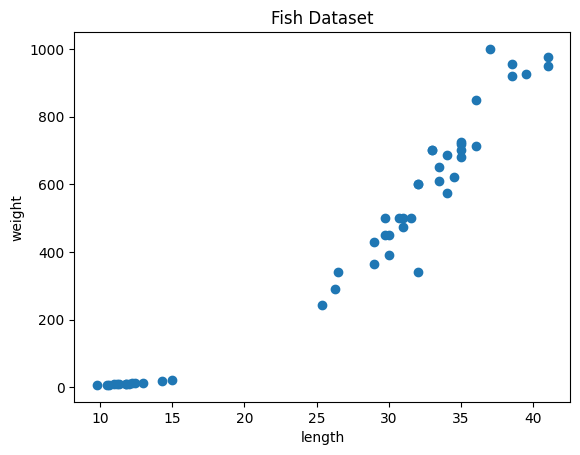

In [3]:
#@title { vertical-output: true}
import matplotlib.pyplot as plt

# IMPLEMENT HERE: scatter plot 작성

plt.scatter(input_arr[:, 0], input_arr[:, 1])
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Fish Dataset')
plt.show()

---
## Part 2: 순차적 분할 (20점)

데이터를 순서대로 분할하면 어떤 문제가 발생하는지 확인합니다.

---

### 문제 2-1. 순차적 분할 [20점]

처음 35개를 훈련 데이터, 나머지 14개를 테스트 데이터로 분할합니다.

**문제:** 슬라이싱을 사용하여 데이터를 분할하세요.

**힌트:**
```python
train_input = input_arr[:35]
train_target = target_arr[:35]
test_input = input_arr[35:]
test_target = target_arr[35:]
```

**예상 결과:** 훈련 데이터에는 도미만, 테스트 데이터에는 빙어만 포함되는 문제 발생

훈련 데이터 크기: (35, 2)
테스트 데이터 크기: (14, 2)
훈련 타겟 클래스: {np.int64(1)}
테스트 타겟 클래스: {np.int64(0)}


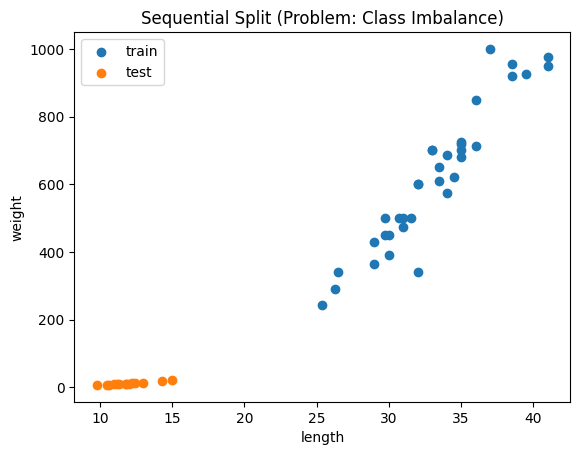

In [4]:
#@title { vertical-output: true}
import matplotlib.pyplot as plt

# IMPLEMENT HERE: 순차적 분할
train_input = input_arr[:35]
train_target = target_arr[:35]

test_input = input_arr[35:]
test_target = target_arr[35:]

print(f"훈련 데이터 크기: {train_input.shape}")
print(f"테스트 데이터 크기: {test_input.shape}")
print(f"훈련 타겟 클래스: {set(train_target)}")
print(f"테스트 타겟 클래스: {set(test_target)}")

# Graph
plt.scatter(train_input[:, 0], train_input[:, 1], label='train')
plt.scatter(test_input[:, 0], test_input[:, 1], label='test')
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Sequential Split (Problem: Class Imbalance)')
plt.legend()
plt.show()

---
## Part 3: 랜덤 셔플 분할 (30점)

인덱스를 랜덤하게 섞어서 데이터를 분할합니다.

---

### 문제 3-1. 랜덤 셔플을 이용한 분할 [30점]

numpy의 random.shuffle을 사용하여 인덱스를 섞은 후 분할합니다.

**문제:**
1. 인덱스 배열 생성 (`np.arange`)
2. 인덱스 셔플 (`np.random.shuffle`)
3. 셔플된 인덱스로 데이터 분할

**힌트:**
```python
index = np.arange(len(input_arr))
np.random.shuffle(index)
train_input = input_arr[index[:35]]
```

**예상 결과:** 훈련/테스트 데이터에 두 클래스가 골고루 분포

원본 인덱스: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]
셔플된 인덱스: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]

훈련 데이터 크기: (35, 2)
테스트 데이터 크기: (14, 2)
훈련 타겟 - 도미: 35, 빙어: 0
테스트 타겟 - 도미: 0, 빙어: 14


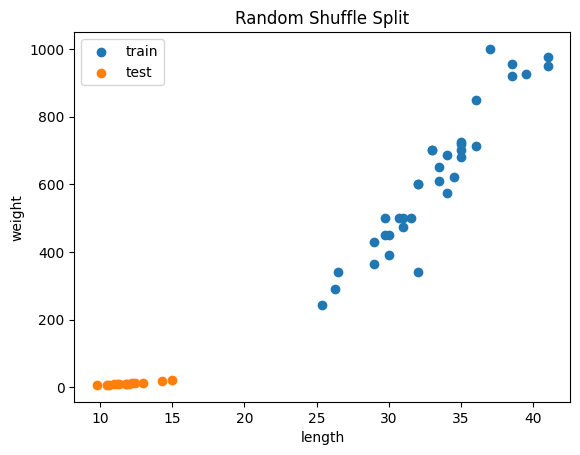

In [5]:
#@title { vertical-output: true}
import matplotlib.pyplot as plt
np.random.seed(42)  # 재현성을 위한 시드 설정

# IMPLEMENT HERE: 인덱스 생성
index = np.arange(len(input_arr))
print("원본 인덱스:", index)

# IMPLEMENT HERE: 인덱스 셔플

print("셔플된 인덱스:", index)

# IMPLEMENT HERE: 셔플된 인덱스로 데이터 분할
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

print(f"\n훈련 데이터 크기: {train_input.shape}")
print(f"테스트 데이터 크기: {test_input.shape}")
print(f"훈련 타겟 - 도미: {sum(train_target==1)}, 빙어: {sum(train_target==0)}")
print(f"테스트 타겟 - 도미: {sum(test_target==1)}, 빙어: {sum(test_target==0)}")

# Graph
plt.scatter(train_input[:, 0], train_input[:, 1], label='train')
plt.scatter(test_input[:, 0], test_input[:, 1], label='test')
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Random Shuffle Split')
plt.legend()
plt.show()

---
## Part 4: sklearn train_test_split (30점)

sklearn의 train_test_split 함수를 사용하여 간편하게 분할합니다.

---

### 문제 4-1. train_test_split 사용 [30점]

sklearn의 train_test_split을 사용하면 자동으로 셔플하고 분할합니다.

**문제:** train_test_split을 사용하여 데이터를 분할하세요.

**힌트:**
```python
train_input, test_input, train_target, test_target = \
    train_test_split(fish_data, fish_target, random_state=42)
```

**주요 파라미터:**
- `test_size`: 테스트 데이터 비율 (기본값 0.25)
- `random_state`: 랜덤 시드
- `stratify`: 클래스 비율 유지

**예상 결과:** 훈련 37개, 테스트 12개로 분할됨

훈련 데이터 크기: (36, 2)
테스트 데이터 크기: (13, 2)
훈련 타겟 - 도미: 25, 빙어: 11
테스트 타겟 - 도미: 10, 빙어: 3


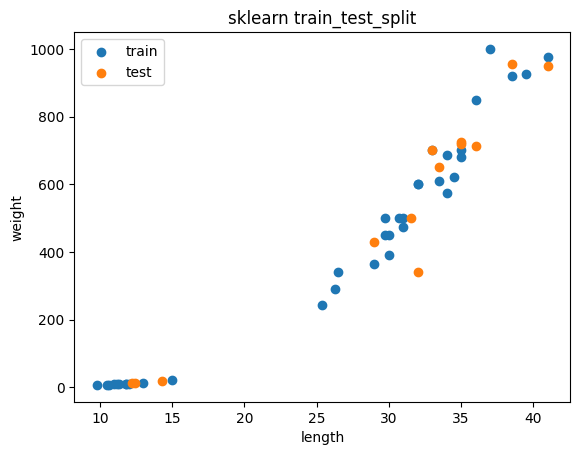

In [9]:
#@title { vertical-output: true}
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# IMPLEMENT HERE: train_test_split 사용
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

# numpy 배열로 변환
train_input = np.array(train_input)
test_input = np.array(test_input)
train_target = np.array(train_target)
test_target = np.array(test_target)

print(f"훈련 데이터 크기: {train_input.shape}")
print(f"테스트 데이터 크기: {test_input.shape}")
print(f"훈련 타겟 - 도미: {sum(train_target==1)}, 빙어: {sum(train_target==0)}")
print(f"테스트 타겟 - 도미: {sum(test_target==1)}, 빙어: {sum(test_target==0)}")

# Graph
plt.scatter(train_input[:, 0], train_input[:, 1], label='train')
plt.scatter(test_input[:, 0], test_input[:, 1], label='test')
plt.xlabel('length')
plt.ylabel('weight')
plt.title('sklearn train_test_split')
plt.legend()
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `dataset_split_학번_이름.ipynb`, `dataset_split_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---